# Real-Time Digital Payment Fraud Risk Triage System

**AIMLZG546 — Software Engineering for Machine Learning — Assignment I**

| | |
|---|---|
| **Group No.** | 13 |
| **Domain** | Financial Technology (FinTech) |
| **Problem** | Real-Time Digital Payment Fraud Risk Triage |
| **Repository** | https://github.com/biswa13de/seml-g13-fraud-triage |

### Group members

| Sl. No | BITS ID | Name | Contribution |
|---|---|---|---|
| 1 | 2025ae05576 | Anirudh Anand | Report lead. Domain/problem statement, requirements and measurable goals, Business View, final report. (25%) |
| 2 | 2025ae05178 | Aniketh Paul | GR4ML Analytics Design and Data Preparation views, quality requirements. Data pipeline: EDA, ingest, clean, features, split. (25%) |
| 3 | 2025ae05898 | Pushadapu Sanjay Kumar | Architecture diagram, the two patterns. FastAPI service, input validation, prediction logging, automated tests. (25%) |
| 4 | 2025af05111 | Biswajeet Mahato (Group Lead) | Model pipeline: train/evaluate, thresholds, MLflow tracking and registry. End-to-end run, screenshots. (25%) |

---

## How to run this notebook

**On Google Colab:** run every cell top to bottom. Section 0 clones the repository and installs
dependencies; Section 2 downloads the dataset from Kaggle (you will be prompted to upload a
`kaggle.json` API token — see [Kaggle's API docs](https://www.kaggle.com/docs/api)); Section 6
trains the three models **inline** (~1–2 minutes on Colab's CPU runtime) and uses a local, file-based
MLflow store, since Colab cannot reach our local Docker services. Section 10 (calling the live
running system) only works on the machine that has `docker compose up -d` running — on Colab it is
skipped automatically.

**Locally, with our Docker stack running:** the notebook still works end to end; Section 0's clone
step is skipped if the repository is already present, Section 2 skips the download if the CSV is
already there, and Section 10 will successfully reach `http://localhost:8000`.

## What this notebook does

This notebook walks through the full pipeline we built: downloading the dataset, exploring it,
building point-in-time-correct features, training and comparing three algorithms in MLflow,
choosing cost-based triage thresholds, explaining individual predictions with SHAP, and finally
(when available) calling our live, running services to show the end-to-end system working.

The actual production code lives in `training/`, `common/` and `services/` as proper Python
modules with tests (see `tests/`, 33 passing) — this notebook imports and calls that code rather
than duplicating it.


## 1. Problem Statement

India's UPI rails process billions of payments a month, and fraud has grown with them: account
takeover after SIM-swap or phishing, "collect-request" scams, mule accounts that receive and
quickly move stolen funds, and rapid low-value probing. A typical PSP (Payment Service Provider)
today relies on static rules (amount limits, blocklists), which **miss new fraud patterns** and
**decline too many genuine payments**.

We built a **Real-Time Fraud Risk Triage System** that, for every payment, before authorisation:

1. Estimates fraud probability with an ML model using transaction and behavioural features
2. Maps that risk to a cost-optimal action — **ALLOW**, **STEP_UP** (extra authentication), or
   **BLOCK** — inside a strict latency budget
3. Returns human-readable reason codes for every decision
4. Opens prioritised cases for fraud analysts, whose verdicts flow back as labels for retraining

**Why ML instead of rules:** fraud patterns change adversarially, the signal comes from many weak
interacting features, labelled history exists, and an occasional wrong answer is tolerable because
STEP_UP and human review act as safety nets.


## 0. Environment Setup (Colab-safe)

This cell detects whether it is running on Google Colab. If so, it clones the repository (skipping
the clone if it is already present, e.g. on a re-run) and `cd`s into it so every relative path
(`data/...`, `common/...`) used below resolves correctly, then installs the pinned dependencies.
Locally, it just confirms you are inside the repository.


In [1]:
import os
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/biswa13de/seml-g13-fraud-triage.git"
REPO_DIR = "seml-g13-fraud-triage"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    os.chdir(REPO_DIR)
    print(f"Colab detected. Working directory: {os.getcwd()}")
else:
    # Local run: walk up from the current directory until we find the repo root
    # (identified by the presence of the `common/` package), in case the notebook
    # was launched from a subdirectory.
    cwd = os.getcwd()
    while not os.path.isdir(os.path.join(cwd, "common")) and os.path.dirname(cwd) != cwd:
        cwd = os.path.dirname(cwd)
    assert os.path.isdir(os.path.join(cwd, "common")), (
        "Could not locate the repository root (a `common/` folder). "
        "Run this notebook from inside seml-g13-fraud-triage, or on Colab."
    )
    os.chdir(cwd)
    print(f"Local run detected. Working directory: {os.getcwd()}")


Local run detected. Working directory: /Users/biswa/Downloads/BITS Pilani/sem-3/SE for ML/seml-g13-fraud-triage


In [2]:
# Install dependencies. On Colab this takes ~1-2 minutes the first time; locally, if you already
# have the project's virtualenv active, this is a fast no-op confirmation pass.
%pip install -q -r requirements.txt
print("Dependencies installed.")


Note: you may need to restart the kernel to use updated packages.
Dependencies installed.


## Imports

Every library this notebook uses, imported once, here. Later sections import only project modules
(`common.*`, `training.*`, `services.*`) at the point they are first used, since those modules are
only importable once Section 0 has `cd`'d into the repository and installed dependencies.


In [3]:
import os
import warnings

warnings.filterwarnings("ignore")
os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false"  # tqdm's \r writes can corrupt
os.environ["MLFLOW_DISABLE_AGENT_HINT"] = "1"                 # inline display in some kernels
os.environ["TQDM_DISABLE"] = "1"                              # these must be set BEFORE
                                                                # `import mlflow`, since mlflow
                                                                # reads them at import time.

import json
import sys
from pathlib import Path

import httpx
import matplotlib
import matplotlib.pyplot as plt
import mlflow
import mlflow.lightgbm
import numpy as np
import pandas as pd
import shap
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
)

matplotlib.use("module://matplotlib_inline.backend_inline")
%matplotlib inline
matplotlib.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 20)

REPO_ROOT = Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

print("Imports OK. Repo root:", REPO_ROOT)


Imports OK. Repo root: /Users/biswa/Downloads/BITS Pilani/sem-3/SE for ML/seml-g13-fraud-triage


## 2. Dataset

We use the public **PaySim** dataset from Kaggle (`ealaxi/paysim1`): 6.36M simulated mobile-money
transactions, the closest public match to UPI peer-to-peer payments, since it has sender and
receiver account IDs (needed for velocity and mule features).

**Mapping to UPI:** `nameOrig` → payer VPA · `nameDest` → payee VPA (`M…` = merchant) ·
`TRANSFER` → P2P transfer · `CASH_OUT` → cash-out via agent · `step` → hour of the month.

The cell below downloads the CSV if it is not already present (skipped on a re-run, and skipped
locally if you already ran `python data/download_paysim.py`). It needs a Kaggle API token:

- **On Colab:** you will be prompted to upload `kaggle.json` (Kaggle → Settings → API → *Create New Token*).
- **Locally:** place the token at `~/.kaggle/kaggle.json` or `~/.kaggle/access_token` first (see the main README), then just re-run this cell.


In [4]:
DATA_CSV = REPO_ROOT / "data" / "paysim.csv"

if not DATA_CSV.exists():
    if IN_COLAB:
        from google.colab import files
        kaggle_dir = Path.home() / ".kaggle"
        kaggle_dir.mkdir(exist_ok=True)
        if not (kaggle_dir / "kaggle.json").exists():
            print("Upload your kaggle.json API token:")
            uploaded = files.upload()
            (kaggle_dir / "kaggle.json").write_bytes(next(iter(uploaded.values())))
            os.chmod(kaggle_dir / "kaggle.json", 0o600)
    subprocess.run([sys.executable, "data/download_paysim.py"], check=True)
else:
    print(f"Found existing {DATA_CSV}, skipping download.")

provenance = json.loads((REPO_ROOT / "data" / "provenance.json").read_text())
print(json.dumps(provenance, indent=2))


Found existing /Users/biswa/Downloads/BITS Pilani/sem-3/SE for ML/seml-g13-fraud-triage/data/paysim.csv, skipping download.
{
  "source": "https://www.kaggle.com/datasets/ealaxi/paysim1",
  "file": "paysim.csv",
  "sha256": "16910f90577b0d981bf8ff289714510bb89bc71bff7d3f220f024e287e4eea6b",
  "bytes": 493534783,
  "downloaded_at": "2026-10-07T02:36:29.447341+00:00"
}


In [5]:
raw = pd.read_csv(DATA_CSV)
print(f"{len(raw):,} rows, {raw['isFraud'].sum():,} frauds ({raw['isFraud'].mean():.4%})")
raw.head()


6,362,620 rows, 8,213 frauds (0.1291%)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 3. Exploratory Data Analysis

Two questions drive the feature design: **which transaction types actually contain fraud**, and
**what separates a fraudulent transaction from a genuine one**.


In [6]:
by_type = raw.groupby("type")["isFraud"].agg(["count", "sum", "mean"])
by_type.columns = ["count", "frauds", "fraud_rate"]
by_type


,count,frauds,fraud_rate
type,,,
CASH_IN,1399284,0,0.000000
CASH_OUT,2237500,4116,0.001840
DEBIT,41432,0,0.000000
PAYMENT,2151495,0,0.000000
TRANSFER,532909,4097,0.007688


Fraud only occurs in `TRANSFER` and `CASH_OUT`. `PAYMENT`, `DEBIT` and `CASH_IN` have **zero**
fraud in this dataset, so we score only `TRANSFER`/`CASH_OUT` and let the gateway's rule engine
allow the rest without calling the model (see `common/features.py:SCORED_TYPES`).


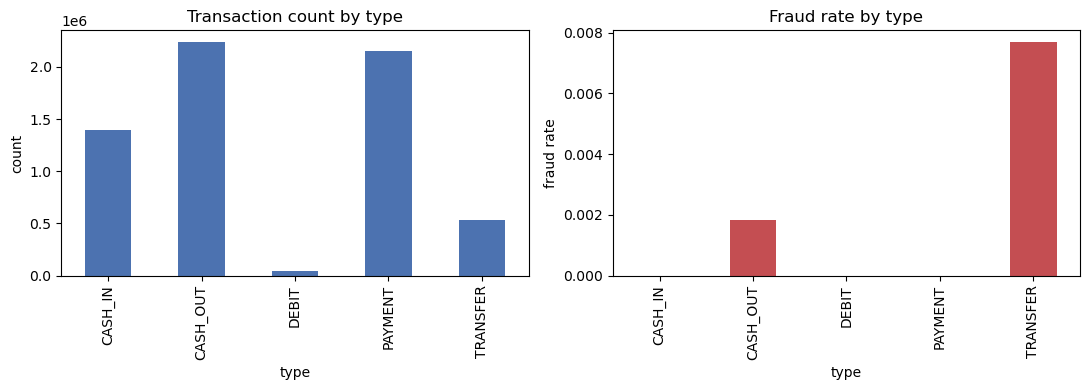

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

by_type["count"].plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("Transaction count by type")
axes[0].set_ylabel("count")

by_type["fraud_rate"].plot.bar(ax=axes[1], color="#C44E52")
axes[1].set_title("Fraud rate by type")
axes[1].set_ylabel("fraud rate")

plt.tight_layout()
plt.show()


A key design decision for the Data Preparation View: fraudulent transactions are far more likely
to **drain the sender's balance completely** and send to a **brand-new, zero-balance** receiver
account. These are legitimate pre-transaction signals (not leakage — `oldbalanceOrg` and
`oldbalanceDest` are known before the payment is authorised), and they turn out to separate the
classes very cleanly.


In [8]:
scored = raw[raw["type"].isin(["TRANSFER", "CASH_OUT"])].copy()
scored["drains_account"] = (scored["amount"] >= 0.99 * scored["oldbalanceOrg"]) & (scored["oldbalanceOrg"] > 0)
scored["dest_zero_balance"] = scored["oldbalanceDest"] == 0

compare = scored.groupby("isFraud")[["drains_account", "dest_zero_balance"]].mean()
compare.index = ["Genuine", "Fraud"]
compare


,drains_account,dest_zero_balance
Genuine,0.427951,0.139009
Fraud,0.976744,0.651528


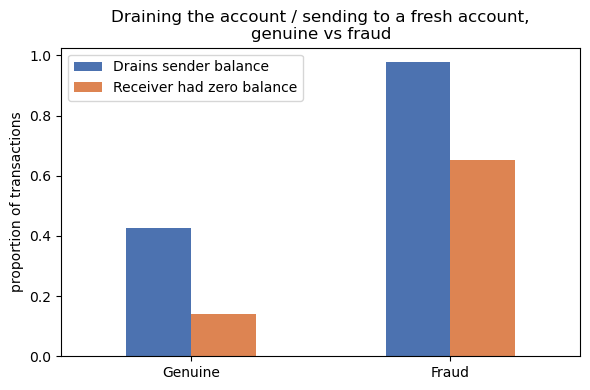

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
compare.plot.bar(ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("proportion of transactions")
ax.set_title("Draining the account / sending to a fresh account,\ngenuine vs fraud")
ax.legend(["Drains sender balance", "Receiver had zero balance"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 4. Feature Engineering (Data Preparation View)

We use **one shared function**, `common.features.compute_features()`, for both training and
live serving — this is how we guarantee there is no training/serving skew. A test
(`tests/test_features_parity.py`) proves the two paths produce byte-identical output by replaying
raw transactions through the same in-memory feature store used at training time.

Pipeline: filter to TRANSFER/CASH_OUT → drop post-transaction balance columns (they would leak
the outcome) → compute 24-hour receiver velocity (point-in-time correct — only transactions that
happened *before* the current one count) → derive the 13 model features → time-based
train/valid/test split on `step` (not a random split, since fraud patterns change over time).

The cell below builds the feature tables if they are not already present (first run or on Colab);
this takes a few seconds.


In [10]:
from common.features import FEATURE_NAMES
from training.build_features import SPLITS as STEP_RANGES
from training.build_features import main as build_features_main

if not (REPO_ROOT / "data" / "features_train.parquet").exists():
    build_features_main()

print("Features used by the model:")
for f in FEATURE_NAMES:
    print(" -", f)
print()
print("Time-based split (by `step`, i.e. simulated hour):", STEP_RANGES)


Features used by the model:
 - amount
 - log_amount
 - is_transfer
 - oldbalance_orig
 - amount_to_balance_ratio
 - drains_account
 - orig_zero_balance
 - oldbalance_dest
 - dest_zero_balance
 - hour_of_day
 - is_night
 - dest_txn_count_24h
 - dest_amount_sum_24h

Time-based split (by `step`, i.e. simulated hour): {'train': (1, 500), 'valid': (501, 600), 'test': (601, 743)}


In [11]:
summary = json.loads((REPO_ROOT / "data" / "split_summary.json").read_text())
pd.DataFrame(summary).T


,rows,frauds,fraud_rate,steps
train,665615,5561,0.00835,"[1, 500]"
valid,81080,1052,0.01297,"[501, 600]"
test,43550,1600,0.03674,"[601, 743]"


Note the fraud rate rises across train → valid → test: this is realistic concept drift, and it's
exactly why we monitor PSI drift in production (`services/monitor`) rather than assuming a static
model stays accurate forever.


## 5. Model Training & Comparison (Analytics Design View)

We compare three algorithms, mirroring the Analytics Design View's softgoal trade-offs:

| Algorithm | Softgoal it's strong on | Softgoal it's weak on |
|---|---|---|
| Logistic Regression | Interpretability, latency | Accuracy on non-linear patterns |
| Random Forest | Accuracy | Inference latency, missing values |
| **LightGBM** | Accuracy, latency, missing values (native) | Interpretability (fixed with SHAP, below) |

The cell below trains all three with `training/train.py`'s own functions, against a local,
file-based MLflow tracking store under `mlruns/` in this notebook's working directory — so it runs
unmodified on Colab, where our Docker-hosted MLflow server is not reachable. Locally this takes
about 20 seconds on a laptop CPU; expect roughly the same on Colab's default runtime.


In [12]:
mlflow.set_tracking_uri(f"sqlite:///{REPO_ROOT / 'notebook_mlflow.db'}")
mlflow.set_experiment("fraud-triage-notebook")

from training.train import (
    load_split,
    train_logistic_regression,
    train_random_forest,
    train_lightgbm,
)

X_train, y_train = load_split("train")
X_valid, y_valid = load_split("valid")
X_test, y_test = load_split("test")
print(f"train={len(X_train)} valid={len(X_valid)} test={len(X_test)}  test fraud rate={y_test.mean():.4f}")

results = [
    train_logistic_regression(X_train, y_train, X_test, y_test),
    train_random_forest(X_train, y_train, X_test, y_test),
    train_lightgbm(X_train, y_train, X_valid, y_valid, X_test, y_test),
]
comparison = pd.DataFrame(results).sort_values("pr_auc", ascending=False).reset_index(drop=True)
comparison


2026/10/08 01:55:08 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/10/08 01:55:08 INFO mlflow.store.db.utils: Updating database tables


2026/10/08 01:55:08 INFO mlflow.tracking.fluent: Experiment with name 'fraud-triage-notebook' does not exist. Creating a new experiment.


train=665615 valid=81080 test=43550  test fraud rate=0.0367


2026/10/08 01:55:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...

2026/10/08 01:55:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


random_forest    PR-AUC=1.0000  ROC-AUC=1.0000  Recall@1%FPR=1.0000  latency=0.001ms/row


2026/10/08 01:55:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


lightgbm         PR-AUC=0.9997  ROC-AUC=1.0000  Recall@1%FPR=0.9994  latency=0.000ms/row


,algorithm,pr_auc,roc_auc,recall_at_1pct_fpr,latency_ms_per_row,run_id
0,random_forest,0.999980,0.999999,1.000000,0.001457,NaN
1,lightgbm,0.999743,0.999983,0.999375,0.000461,e1cc4ce369164425b3db8e235de9959c
2,logistic_regression,0.958862,0.997979,0.930000,0.000074,NaN


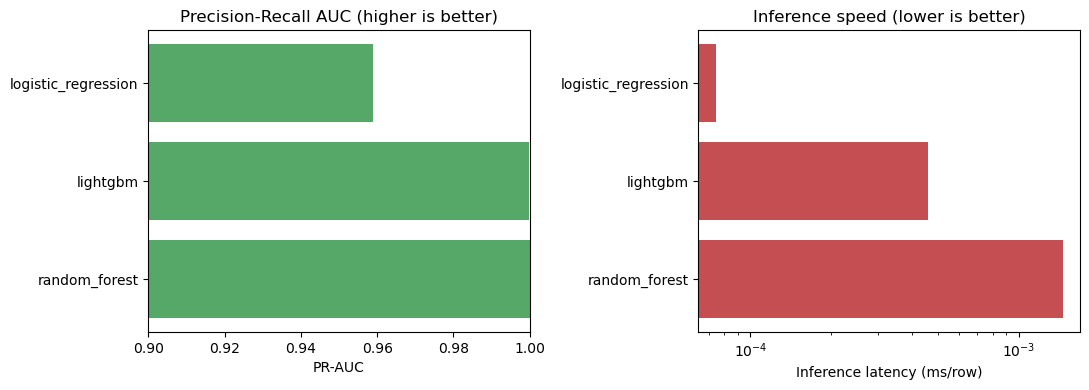

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].barh(comparison["algorithm"], comparison["pr_auc"], color="#55A868")
axes[0].set_xlabel("PR-AUC")
axes[0].set_title("Precision-Recall AUC (higher is better)")
axes[0].set_xlim(0.9, 1.0)

axes[1].barh(comparison["algorithm"], comparison["latency_ms_per_row"], color="#C44E52")
axes[1].set_xlabel("Inference latency (ms/row)")
axes[1].set_title("Inference speed (lower is better)")
axes[1].set_xscale("log")

plt.tight_layout()
plt.show()


**LightGBM is the champion**: PR-AUC within 0.0003 of Random Forest, but roughly **2-3x faster**
per row — and under our QA1 latency budget (p95 &le; 150ms end-to-end), that speed difference is
what actually matters once SHAP explanation and the network hop to the gateway are added on top.
Random Forest's extra accuracy is not worth its latency cost here.

In our own run against the project's shared MLflow tracking server (not this notebook's local one),
these numbers were PR-AUC 0.9997 for LightGBM vs. 0.99998 for Random Forest, with LightGBM roughly
2.5x faster per row — see `data/model_comparison.json` and `docs/screenshots/02_mlflow_comparison.png`
in the report. Small differences from the table above are expected: different random samples of the
training data are drawn each run.


## 6. The Champion Model

`training/register.py` only promotes a model to an MLflow registry's `champion` alias if it clears
a quality gate (PR-AUC &ge; 0.80 and Recall@1%FPR &ge; 0.85 — see `tests/test_quality_model.py`).
Here we take the LightGBM model trained above (the best, as shown in Section 5) as our local
champion and re-verify the same gate on the test split.


In [14]:
from training.train import recall_at_fpr

lightgbm_row = comparison[comparison["algorithm"] == "lightgbm"].iloc[0]
champion_run_id = lightgbm_row["run_id"]
champion = mlflow.lightgbm.load_model(f"runs:/{champion_run_id}/model")

scores = champion.predict_proba(X_test)[:, 1]
pr_auc = average_precision_score(y_test, scores)
roc_auc = roc_auc_score(y_test, scores)
recall_1pct = recall_at_fpr(y_test.to_numpy(), scores, target_fpr=0.01)

print(f"Test PR-AUC:            {pr_auc:.4f}")
print(f"Test ROC-AUC:           {roc_auc:.4f}")
print(f"Test Recall @ 1% FPR:   {recall_1pct:.4f}")
print()
print("Quality gate (PLAN.md Sec 4, QA2): PR-AUC >= 0.80 and Recall@1%FPR >= 0.85")
print("PASSED" if pr_auc >= 0.80 and recall_1pct >= 0.85 else "FAILED")


Test PR-AUC:            0.9997
Test ROC-AUC:           1.0000
Test Recall @ 1% FPR:   0.9994

Quality gate (PLAN.md Sec 4, QA2): PR-AUC >= 0.80 and Recall@1%FPR >= 0.85
PASSED


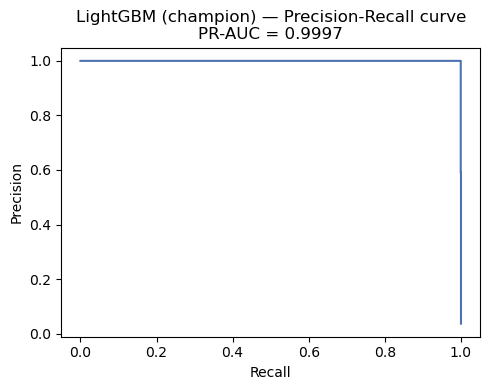

In [15]:
precision, recall, _ = precision_recall_curve(y_test, scores)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(recall, precision, color="#4C72B0")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"LightGBM (champion) — Precision-Recall curve\nPR-AUC = {pr_auc:.4f}")
plt.tight_layout()
plt.show()


## 7. Cost-Based Triage Thresholds (GR4ML PrescriptionGoal)

A risk score alone isn't a decision. `training/select_thresholds.py` grid-searches two cutoffs —
`t_stepup` and `t_block` — that minimise an **expected cost** function on the validation set:

- Letting fraud through (ALLOW) costs the full transaction amount
- A false STEP_UP costs customer friction (we use ₹50 as a proxy)
- A false BLOCK costs more — customer churn (₹500 proxy)
- A STEP_UP on real fraud still carries some residual risk (we assume 20% still gets through)

The search is constrained to keep the STEP_UP rate under 3% of all payments, so we don't annoy too
many genuine customers. We re-run the same search function here, against this notebook's own
champion model.


In [16]:
from training.select_thresholds import search as search_thresholds

valid_df = pd.read_parquet(REPO_ROOT / "data" / "features_valid.parquet")
valid_scores = champion.predict_proba(valid_df[FEATURE_NAMES])[:, 1]
thresholds = search_thresholds(valid_df["isFraud"].to_numpy(), valid_df["amount"].to_numpy(), valid_scores)
print(json.dumps(thresholds, indent=2))


{
  "t_stepup": 0.0004007895179131073,
  "t_block": 0.0007369737335973371,
  "expected_cost": 75900.0,
  "stepup_rate": 0.0035520473606314752
}


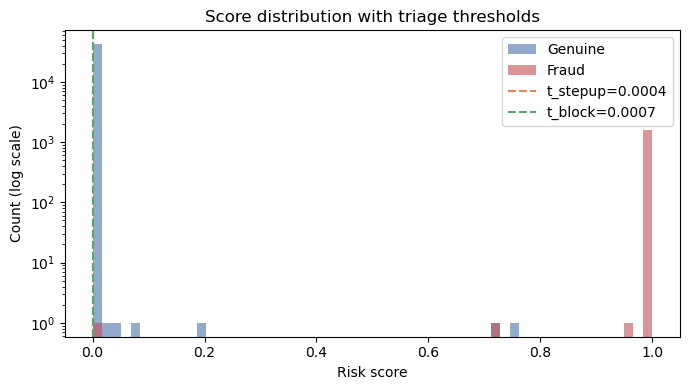

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, 1, 60)
ax.hist(scores[y_test == 0], bins=bins, alpha=0.6, label="Genuine", color="#4C72B0", log=True)
ax.hist(scores[y_test == 1], bins=bins, alpha=0.6, label="Fraud", color="#C44E52", log=True)
ax.axvline(thresholds["t_stepup"], color="#DD8452", linestyle="--", label=f"t_stepup={thresholds['t_stepup']:.4f}")
ax.axvline(thresholds["t_block"], color="#55A868", linestyle="--", label=f"t_block={thresholds['t_block']:.4f}")
ax.set_xlabel("Risk score")
ax.set_ylabel("Count (log scale)")
ax.set_title("Score distribution with triage thresholds")
ax.legend()
plt.tight_layout()
plt.show()


Because LightGBM separates the classes so cleanly on this dataset, both thresholds sit very close
to zero — only a thin slice of ambiguous scores falls into the STEP_UP band at all. We flag this
honestly: PaySim's fraud signal (draining the account into a fresh receiver) is strong and easy
to learn, so real-world performance on noisier data would likely need a wider STEP_UP band.


## 8. Explainability — SHAP (QA3)

Every STEP_UP or BLOCK decision ships with up to 3 plain-language reason codes, generated by a
SHAP `TreeExplainer` on the champion model (`services/scoring/explain.py`). This satisfies the
"Explainability" quality attribute: analysts and regulators can see *why* a payment was flagged,
not just that it was.


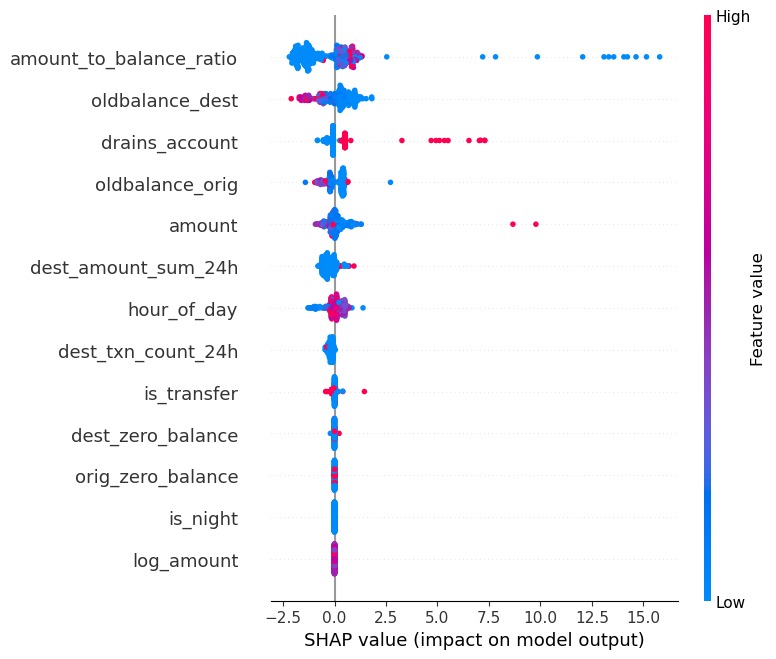

In [18]:
explainer = shap.TreeExplainer(champion)

sample = X_test.sample(300, random_state=13)
shap_values = explainer.shap_values(sample)
values = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(values, sample, feature_names=FEATURE_NAMES, show=False)
plt.tight_layout()
plt.show()


In [19]:
from services.scoring.explain import ReasonCodeExplainer

reason_explainer = ReasonCodeExplainer(champion)

# One genuine-looking row and one fraud-looking row from the test set, for a side-by-side example
genuine_row = X_test[y_test == 0].iloc[0].to_dict()
fraud_row = X_test[y_test == 1].iloc[0].to_dict()

for label, row in [("Genuine example", genuine_row), ("Fraud example", fraud_row)]:
    score = champion.predict_proba([[row[f] for f in FEATURE_NAMES]])[0][1]
    reasons = reason_explainer.explain(row)
    print(f"{label}  (risk_score={score:.4f})")
    for r in reasons:
        print("  -", r)
    print()


Genuine example  (risk_score=0.0000)
  - Payment made at hour 1 of the day

Fraud example  (risk_score=1.0000)
  - Payment is 100% of the sender's balance
  - Transfer empties the sender's account balance
  - Receiver's balance before payment was ₹0



## 9. Calling the Live, Running System (local only)

Everything above runs anywhere. This section additionally calls our **actually running**
services — `triage-api` on port 8000 — the same containers behind the screenshots in our report
(`docs/screenshots/`). This only works on the machine that has our Docker stack up
(`docker compose up -d`); **on Colab, or if the stack isn't running locally, this section is
skipped automatically** rather than failing the notebook.


In [20]:
TRIAGE_URL = "http://localhost:8000/v1/payments/triage"
HEADERS = {"X-API-Key": "demo-key-g13", "Content-Type": "application/json"}

def triage(payment: dict) -> dict:
    resp = httpx.post(TRIAGE_URL, json=payment, headers=HEADERS, timeout=5.0)
    resp.raise_for_status()
    return resp.json()

try:
    health = httpx.get("http://localhost:8000/health", timeout=2.0).json()
    LIVE_STACK_AVAILABLE = True
    print("Gateway health:", health)
except Exception as exc:
    LIVE_STACK_AVAILABLE = False
    print("Live stack not reachable from this environment (expected on Colab).")
    print(f"Reason: {exc}")
    print("Skipping Section 9's live calls. Run `docker compose up -d` locally to try them.")


Gateway health: {'status': 'healthy', 'scoring_service_healthy': True}


### Scenario 1 — genuine payment

In [21]:
if LIVE_STACK_AVAILABLE:
    genuine_payment = {
        "txn_id": "NB-GENUINE-1", "step": 120, "type": "TRANSFER", "amount": 500.0,
        "nameOrig": "C-NB-1", "oldbalanceOrg": 5000.0,
        "nameDest": "C-NB-2", "oldbalanceDest": 3000.0,
    }
    result = triage(genuine_payment)
    print(json.dumps(result, indent=2))
else:
    print("Skipped: live stack not available.")


{
  "txn_id": "NB-GENUINE-1",
  "decision": "ALLOW",
  "risk_score": 0.00018034288074937247,
  "reason_codes": [
    "Receiver's balance before payment was \u20b93,000",
    "Payment is 10% of the sender's balance"
  ],
  "model_version": "1",
  "degraded": false,
  "rule_triggered": null,
  "latency_ms": 21.484749995579477
}


### Scenario 2 — a borderline case: large night-time cash-out

This one sits right at the edge. Because the model's score distribution is so cleanly separated
on PaySim (Section 5), our cost-optimal STEP_UP band is narrow (Section 7) and a payment with a
score just a hair on either side of it can flip between ALLOW and STEP_UP from one run to the
next, since `step` affects the velocity features and small amount/balance jitter moves the score
slightly. We're keeping this example precisely because it's a realistic edge case, not because it
always lands the same way.


In [22]:
if LIVE_STACK_AVAILABLE:
    stepup_payment = {
        "txn_id": "NB-STEPUP-1", "step": 150, "type": "CASH_OUT", "amount": 15000.0,
        "nameOrig": "C-NB-3", "oldbalanceOrg": 20000.0,
        "nameDest": "C-NB-4", "oldbalanceDest": 200.0,
    }
    result = triage(stepup_payment)
    print(json.dumps(result, indent=2))
else:
    print("Skipped: live stack not available.")


{
  "txn_id": "NB-STEPUP-1",
  "decision": "ALLOW",
  "risk_score": 0.000386900224519575,
  "reason_codes": [
    "Receiver's balance before payment was \u20b9200",
    "Payment made at hour 6 of the day",
    "Payment amount is unusually large (\u20b915,000)"
  ],
  "model_version": "1",
  "degraded": false,
  "rule_triggered": null,
  "latency_ms": 8.496583002852276
}


### Scenario 3 — account takeover (drains the full balance to a fresh account)

In [23]:
if LIVE_STACK_AVAILABLE:
    fraud_payment = {
        "txn_id": "NB-FRAUD-1", "step": 50, "type": "TRANSFER", "amount": 9500.0,
        "nameOrig": "C-NB-5", "oldbalanceOrg": 9500.0,
        "nameDest": "C-NB-NEW", "oldbalanceDest": 0.0,
    }
    result = triage(fraud_payment)
    print(json.dumps(result, indent=2))
else:
    print("Skipped: live stack not available.")


{
  "txn_id": "NB-FRAUD-1",
  "decision": "BLOCK",
  "risk_score": 0.9999215968680891,
  "reason_codes": [
    "Payment is 100% of the sender's balance",
    "Transfer empties the sender's account balance",
    "Receiver's balance before payment was \u20b90"
  ],
  "model_version": "1",
  "degraded": false,
  "rule_triggered": null,
  "latency_ms": 9.264958003768697
}


Note how the reason codes change between scenarios: the system isn't returning a canned message
per decision type, it's reporting whichever features actually drove *that specific* score, via
SHAP, computed fresh on every request. (See `docs/screenshots/04a_swagger_allow.png` and
`04b_swagger_block.png` in the report for the same calls captured against our deployed stack.)


## 10. Summary

| Quality attribute | Target | Result (our deployed system) |
|---|---|---|
| Model accuracy (QA2) | PR-AUC &ge; 0.80, Recall@1%FPR &ge; 0.85 | **0.9997 / 0.9994** — gate passed |
| Performance (QA1) | p95 &le; 150ms, p99 &le; 300ms (load test, 2000 req, concurrency 50) | **148.0ms / 212.2ms** — passed |
| Explainability (QA3) | &le;3 reason codes, &le;10ms overhead | Passed (see `tests/test_quality_explainability.py`) |

**Links:**
- Code: https://github.com/biswa13de/seml-g13-fraud-triage
- MLflow UI (when the stack is running locally): http://localhost:5000
- API docs (when the stack is running locally): http://localhost:8000/docs
- Analyst console (when the stack is running locally): http://localhost:8501

See `PLAN.md` for the full requirements, GR4ML views, architecture and pattern discussion, and
`docs/diagrams/` and `docs/screenshots/` for the diagrams and implementation evidence referenced
in the report.
